## Descriptive Statistics and Distributions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

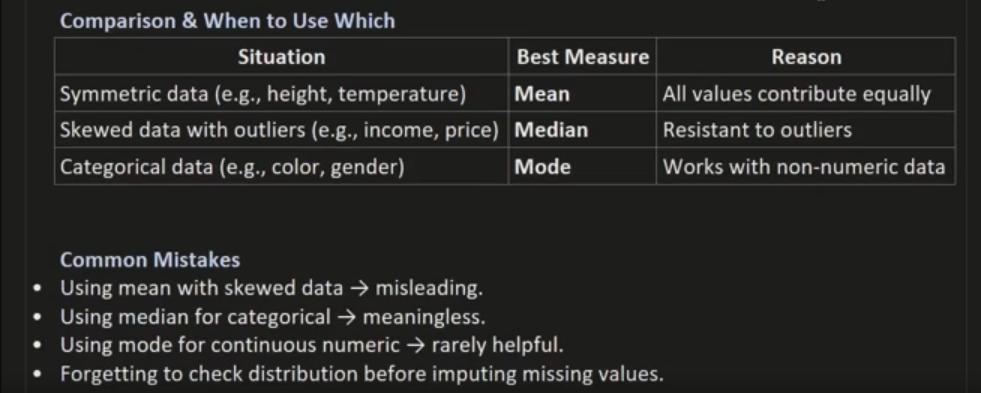

In [2]:
from sklearn.impute import SimpleImputer
imputer_mean = SimpleImputer(strategy='mean')
imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

## Variance and standard deviation

In [3]:
data = [10, 12, 13, 15, 18]
print("Variance:", np.var(data))
print("Standard Deviation:", np.std(data))

Variance: 7.44
Standard Deviation: 2.727636339397171


In [4]:
data = [120, 130, 125, 140, 135, 200, 220]
df = pd.DataFrame({'Purchase': data})

mean = np.mean(df['Purchase'])
pop_var = np.var(df['Purchase'], ddof=0)   # population variance
samp_var = np.var(df['Purchase'], ddof=1)  # sample variance
pop_sd = np.std(df['Purchase'], ddof=0)    # population SD
samp_sd = np.std(df['Purchase'], ddof=1)   # sample SD

print("Mean:", mean)
print("Population Variance:", pop_var)
print("Sample Variance:", samp_var)
print("Population SD:", pop_sd)
print("Sample SD:", samp_sd)

Mean: 152.85714285714286
Population Variance: 1370.4081632653063
Sample Variance: 1598.8095238095239
Population SD: 37.019024342428395
Sample SD: 39.9851162785545


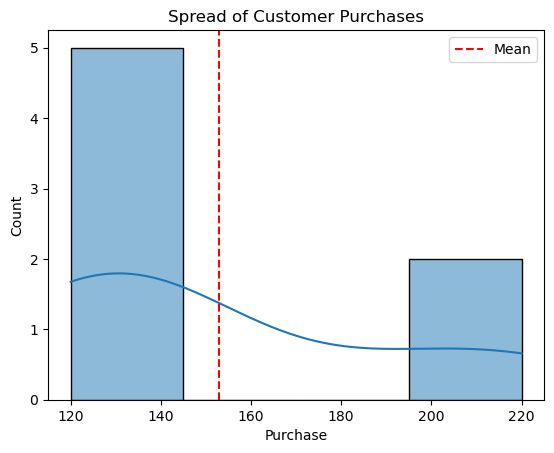

In [5]:
sns.histplot(df['Purchase'], kde=True)
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.legend()
plt.title('Spread of Customer Purchases')
plt.show()

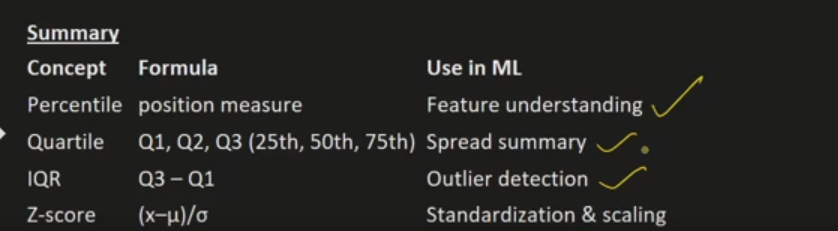

## Percentile IQR Z-scores

In [6]:
import numpy as np
data = [10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40]
print("25th percentile (Q1):", np.percentile(data, 25))
print("50th percentile (Median):", np.percentile(data, 50))
print("75th percentile (Q3):", np.percentile(data, 75))

25th percentile (Q1): 15.75
50th percentile (Median): 24.0
75th percentile (Q3): 33.0


In [27]:
data = [12, 18, 20, 28, 35]
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Outlier Range:", lower_bound, "to", upper_bound)

IQR: 10.0
Outlier Range: 3.0 to 43.0


In [12]:
data = np.array([10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40])

mean = data.mean()
std = data.std()
z_scores = [(x - mean) / std for x in data]
print("Zscores: ", np.round(z_scores, 2))

Zscores:  [-1.5  -1.29 -1.19 -0.98 -0.66 -0.35 -0.14  0.07  0.38  0.59  1.01  1.11
  1.32  1.63]


In [20]:
df = pd.DataFrame({'Income': [22, 25, 27, 29, 35, 40, 42, 100, 110, 115]})

# IQR method
Q1 = df['Income'].quantile(0.25)
Q2 = df['Income'].quantile(0.50)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.0 * IQR
upper = Q3 + 1.0 *IQR

outliers_iqr = df[(df['Income'] < lower) | (df['Income'] > upper)]

print("Outliers using IQR:\n", outliers_iqr)

Outliers using IQR:
 Empty DataFrame
Columns: [Income]
Index: []


In [23]:
# Zscore method
mean = df['Income'].mean()
std = df['Income'].std()

df['Z-Score'] = (df['Income'] - mean) / std

outliers_z = df[np.abs(df['Z-Score']) > 2.5]
print("Outliers using Z-score:\n", outliers_z)

Outliers using Z-score:
 Empty DataFrame
Columns: [Income, Z-Score]
Index: []


In [26]:
# Modified Z-score (Robust)

median = df['Income'].median()
mad = np.median(np.abs(df['Income'] - median))
df['Mod-Z'] = 0.6745 * (df['Income'] - median) / mad
outliers_mz = df[np.abs(df['Mod-Z']) > 3.5]
print("Outliers using Modified Z-score:\n", outliers_mz)

Outliers using Modified Z-score:
    Income   Z-Score     Mod-Z
7     100  1.202258  3.665761
8     110  1.466491  4.252283
9     115  1.598607  4.545543


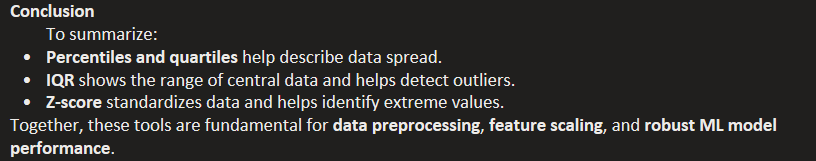

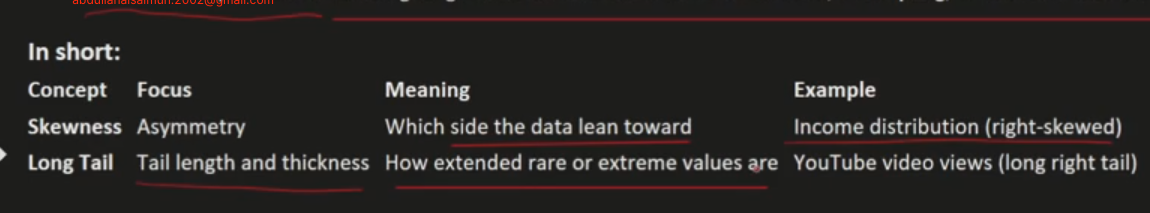

## Practice Module

In [28]:
data = [45, 48, 50, 52, 55, 58, 60, 62, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 150, 500]

In [30]:
## Range

data = np.array(data)
mx = data.max()
mn = data.min()

print(mx - mn)

455


In [32]:
## Variance

print(data.var())

9232.490000000002


In [34]:
## Standard deviation
print(data.std())

96.08584703274464


In [38]:
## Q2 
Q2 = np.quantile(data, .50)
print(Q2)

69.0


In [50]:
Q1 = np.quantile(data, .25)
Q3 = np.quantile(data, .75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlayer = data[(data < lower) | (data > upper)]

outlayer

array([150, 500])